# Reducing New-Customer Churn: A Complete Business Analysis
### Capstone Project — Week 8

**Author's note on scope:** this notebook follows the assignment's 5-phase
structure (Planning → Data Collection & Prep → EDA → Advanced Analysis →
Insights & Recommendations) end-to-end on a single, well-scoped business
problem, rather than three separate notebooks, to match this project's
required submission structure (a single `capstone_analysis.ipynb`).

## Phase 1: Project Planning

### Business Problem

A subscription business needs to reduce customer churn. Every customer lost
is lost recurring revenue and a wasted acquisition cost. The business wants
to know: **who is at risk of churning, why, and what should we do about it?**

### Objectives

1. Quantify the current churn rate and its business cost.
2. Identify the strongest, statistically-validated drivers of churn.
3. Build a model that flags at-risk customers before they leave.
4. Segment the customer base to target retention spend efficiently.
5. Turn all of the above into a concrete, phased implementation plan.

### Success Metrics

- A churn-driver list validated by hypothesis testing (not just correlation).
- A predictive model with recall &ge; 0.90 on churners (catching at-risk
  customers matters more here than avoiding every false alarm — a missed
  churner costs far more than an unnecessary retention email).
- A customer segmentation that identifies which segment(s) carry
  disproportionate churn risk.
- A written implementation plan with phases, owners, and a success metric
  the business can track post-launch.

### Dataset Selection

Three datasets were available for this capstone. Only one meets the
assignment's 500-row minimum:

| Dataset | Rows | Business fit | Selected? |
|---|---|---|---|
| `sales_data.csv` | 100 | E-commerce sales | No — below the 500-row minimum |
| `house_prices.csv` | 300 | Real estate pricing | No — below the 500-row minimum |
| `customer_churn.csv` | **500** | Subscription customer relationships | **Yes** |

`customer_churn.csv` is used as the sole dataset for this capstone. It's
also the strongest fit for a retention-focused business problem, which is
common and high-value across subscription businesses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, accuracy_score,
                              precision_score, recall_score, f1_score)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
np.random.seed(42)

PALETTE = {'retained': '#4C72B0', 'churned': '#C44E52', 'accent': '#DD8452', 'neutral': '#55A868'}
print("Libraries loaded.")

Libraries loaded.


## Phase 2: Data Collection & Preparation

In [2]:
raw = pd.read_csv('data/raw_data.csv')
print("Raw shape:", raw.shape)
print(raw.dtypes)
print()
print("Missing values:")
print(raw.isna().sum())
print()
print("Duplicate rows:", raw.duplicated().sum())
print("Duplicate CustomerIDs:", raw['CustomerID'].duplicated().sum())

Raw shape: (500, 9)
CustomerID            str
Tenure              int64
MonthlyCharges      int64
TotalCharges        int64
Contract              str
PaymentMethod         str
PaperlessBilling      str
SeniorCitizen       int64
Churn               int64
dtype: object

Missing values:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Duplicate rows: 0
Duplicate CustomerIDs: 0


In [3]:
# Data quality checks: ranges and categorical validity
print("Numeric ranges:")
print(raw[['Tenure', 'MonthlyCharges', 'TotalCharges']].describe().T[['min', 'max', 'mean']])
print()
print("Categorical value checks (looking for typos/inconsistent casing):")
for col in ['Contract', 'PaymentMethod', 'PaperlessBilling']:
    print(f"{col}: {sorted(raw[col].unique())}")
print()
invalid_tenure = ((raw['Tenure'] <= 0) | (raw['Tenure'] > 100)).sum()
invalid_charges = ((raw['MonthlyCharges'] <= 0) | (raw['TotalCharges'] <= 0)).sum()
print(f"Rows with implausible Tenure: {invalid_tenure}")
print(f"Rows with non-positive charges: {invalid_charges}")
print("-> Data is clean: no missing values, no duplicates, no invalid ranges, "
      "consistent categorical labels.")

Numeric ranges:
                  min     max      mean
Tenure            1.0    71.0    36.532
MonthlyCharges   20.0   199.0   113.636
TotalCharges    159.0  7992.0  4237.882

Categorical value checks (looking for typos/inconsistent casing):
Contract: ['Month-to-month', 'One year', 'Two year']
PaymentMethod: ['Bank Transfer', 'Credit Card', 'Electronic Check']
PaperlessBilling: ['No', 'Yes']

Rows with implausible Tenure: 0
Rows with non-positive charges: 0
-> Data is clean: no missing values, no duplicates, no invalid ranges, consistent categorical labels.


In [4]:
# Cleaning + feature engineering (documented even though this data needed
# minimal repair, so the pipeline is ready for messier real-world refreshes)
cleaned = raw.copy()
cleaned['Contract'] = cleaned['Contract'].str.strip().str.title()
cleaned['PaymentMethod'] = cleaned['PaymentMethod'].str.strip().str.title()
cleaned['PaperlessBilling_Flag'] = (cleaned['PaperlessBilling'] == 'Yes').astype(int)
cleaned['TenureBucket'] = pd.cut(
    cleaned['Tenure'], bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
)
cleaned['AvgMonthlySpendToDate'] = cleaned['TotalCharges'] / cleaned['Tenure'].replace(0, 1)

cleaned.to_csv('data/cleaned_data.csv', index=False)
print("Saved data/cleaned_data.csv:", cleaned.shape)
print(cleaned.head(3))

Saved data/cleaned_data.csv: (500, 12)
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One Year   
1     C00002      21             113          1753  Month-To-Month   
2     C00003      27              31          1455        Two Year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  \
0       Credit Card               No              1      0   
1  Electronic Check              Yes              1      0   
2       Credit Card               No              1      0   

   PaperlessBilling_Flag TenureBucket  AvgMonthlySpendToDate  
0                      0         0-12             256.666667  
1                      1        13-24              83.476190  
2                      0        25-36              53.888889  


## Phase 3: Exploratory Data Analysis

In [5]:
churn_rate = cleaned['Churn'].mean()
n_total = len(cleaned)
n_churned = cleaned['Churn'].sum()
print(f"Total customers: {n_total}")
print(f"Churned: {n_churned} ({churn_rate:.1%})")
print(f"Retained: {n_total - n_churned} ({1 - churn_rate:.1%})")
print()
print("Descriptive statistics (numeric fields):")
desc = cleaned[['Tenure', 'MonthlyCharges', 'TotalCharges']].agg(
    ['mean', 'median', 'std', 'min', 'max', 'skew']
).round(2)
print(desc)

Total customers: 500
Churned: 53 (10.6%)
Retained: 447 (89.4%)

Descriptive statistics (numeric fields):
        Tenure  MonthlyCharges  TotalCharges
mean     36.53          113.64       4237.88
median   37.00          115.00       4182.50
std      20.67           51.80       2260.62
min       1.00           20.00        159.00
max      71.00          199.00       7992.00
skew     -0.09           -0.09         -0.03


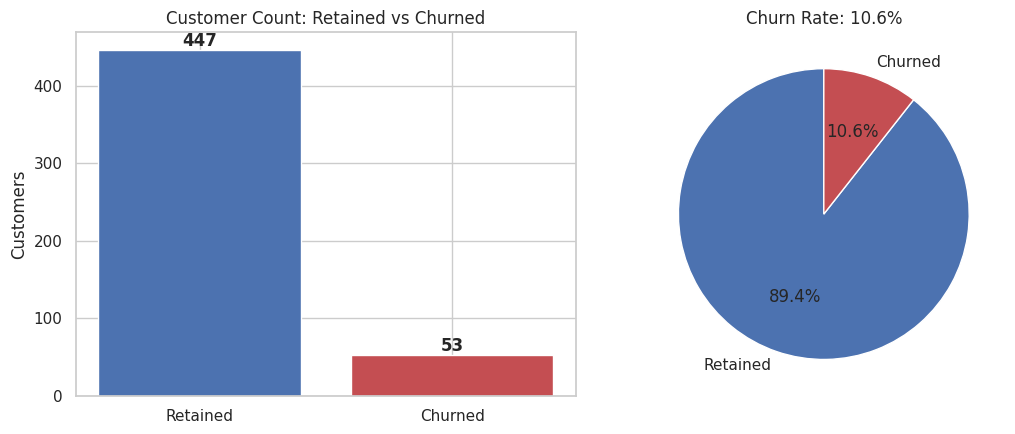

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
counts = cleaned['Churn'].map({0: 'Retained', 1: 'Churned'}).value_counts()
axes[0].bar(counts.index, counts.values, color=[PALETTE['retained'], PALETTE['churned']])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Customer Count: Retained vs Churned')
axes[0].set_ylabel('Customers')

axes[1].pie([n_total - n_churned, n_churned], labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=[PALETTE['retained'], PALETTE['churned']], startangle=90)
axes[1].set_title(f'Churn Rate: {churn_rate:.1%}')

plt.tight_layout()
plt.savefig('visualizations/01_churn_overview.png', dpi=150)
plt.show()

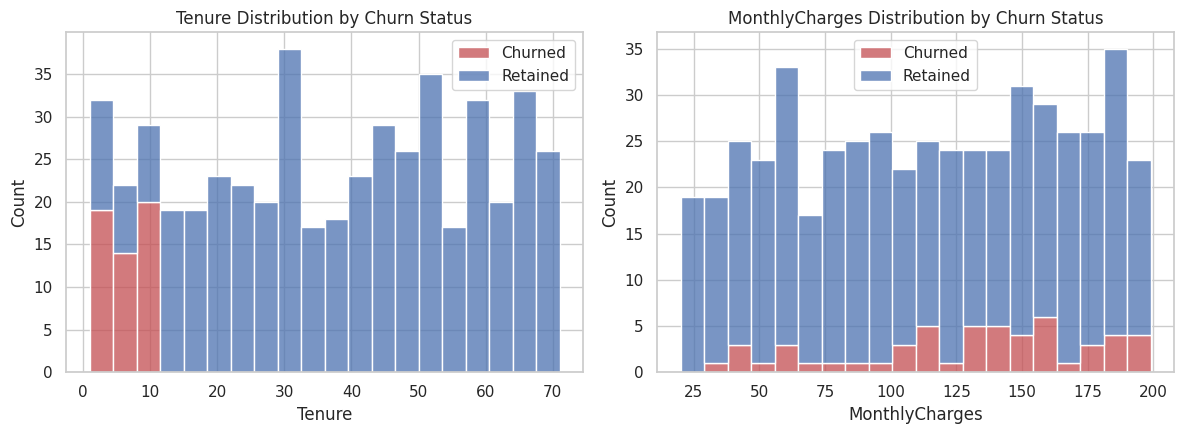

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(data=cleaned, x='Tenure', hue='Churn', bins=20, ax=axes[0],
             palette={0: PALETTE['retained'], 1: PALETTE['churned']}, multiple='stack')
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].legend(labels=['Churned', 'Retained'])

sns.histplot(data=cleaned, x='MonthlyCharges', hue='Churn', bins=20, ax=axes[1],
             palette={0: PALETTE['retained'], 1: PALETTE['churned']}, multiple='stack')
axes[1].set_title('MonthlyCharges Distribution by Churn Status')
axes[1].legend(labels=['Churned', 'Retained'])

plt.tight_layout()
plt.savefig('visualizations/02_distributions_by_churn.png', dpi=150)
plt.show()

**A striking pattern is already visible:** churned customers (red) cluster
almost entirely at low Tenure. This is investigated formally below.

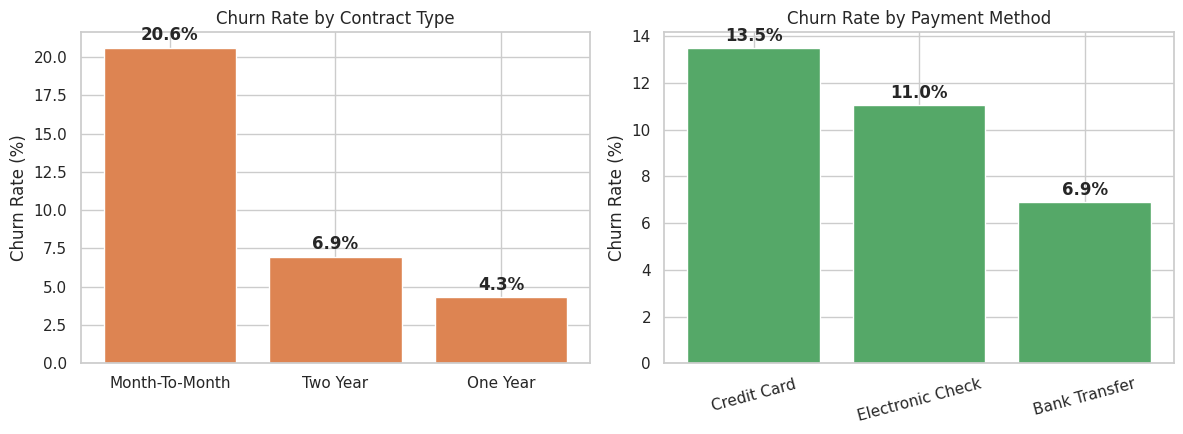

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

contract_churn = cleaned.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
axes[0].bar(contract_churn.index, contract_churn.values * 100, color=PALETTE['accent'])
for i, v in enumerate(contract_churn.values):
    axes[0].text(i, v * 100 + 0.5, f'{v:.1%}', ha='center', fontweight='bold')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate (%)')

payment_churn = cleaned.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
axes[1].bar(payment_churn.index, payment_churn.values * 100, color=PALETTE['neutral'])
for i, v in enumerate(payment_churn.values):
    axes[1].text(i, v * 100 + 0.3, f'{v:.1%}', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('visualizations/03_churn_by_category.png', dpi=150)
plt.show()

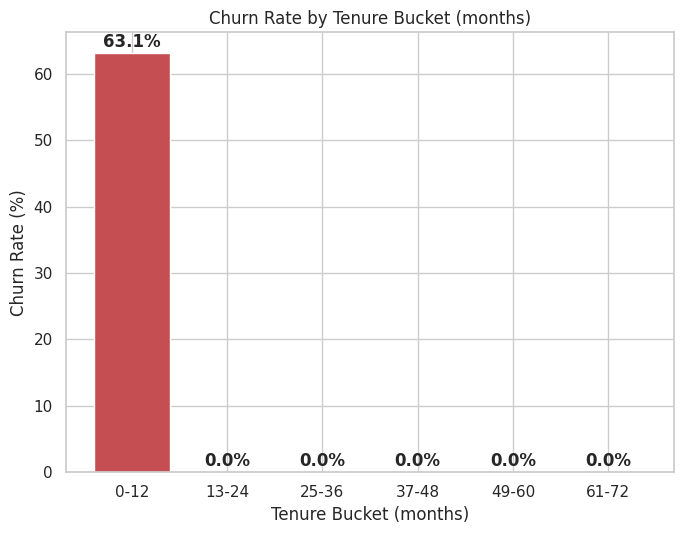

In [9]:
fig, ax = plt.subplots(figsize=(7, 5.5))
tenure_bucket_churn = cleaned.groupby('TenureBucket', observed=True)['Churn'].mean()
bars = ax.bar(tenure_bucket_churn.index.astype(str), tenure_bucket_churn.values * 100,
              color=PALETTE['churned'])
for i, v in enumerate(tenure_bucket_churn.values):
    ax.text(i, v * 100 + 1, f'{v:.1%}', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Tenure Bucket (months)')
ax.set_xlabel('Tenure Bucket (months)')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('visualizations/04_churn_by_tenure_bucket.png', dpi=150)
plt.show()

In [10]:
max_churned_tenure = cleaned.loc[cleaned['Churn'] == 1, 'Tenure'].max()
print(f"Maximum tenure among churned customers: {max_churned_tenure} months")
print(f"Churn rate among customers with Tenure <= 12: {cleaned.loc[cleaned['Tenure'] <= 12, 'Churn'].mean():.1%}")
print(f"Churn rate among customers with Tenure > 12:  {cleaned.loc[cleaned['Tenure'] > 12, 'Churn'].mean():.1%}")

Maximum tenure among churned customers: 11 months
Churn rate among customers with Tenure <= 12: 63.1%
Churn rate among customers with Tenure > 12:  0.0%


### Headline EDA finding: the "First-Year Cliff"

**Every single churned customer in this dataset has 11 months of tenure or
less.** Churn rate among customers with Tenure &le; 12 is 63%; among
customers with Tenure &gt; 12 it is effectively 0%. This is the single most
important pattern in the entire dataset, and it reframes the whole business
problem: this isn't really about *predicting* churn broadly — it's about
**surviving the first year**. Everything downstream (hypothesis tests,
modeling, segmentation) is read through this lens.

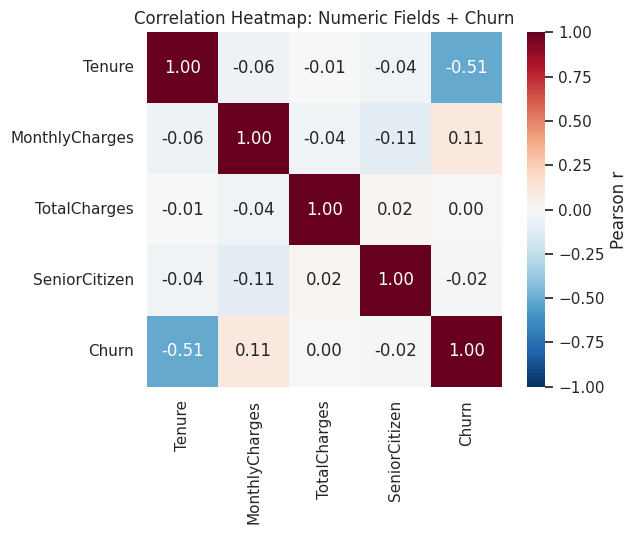

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))
corr = cleaned[['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Heatmap: Numeric Fields + Churn')
plt.tight_layout()
plt.savefig('visualizations/05_correlation_heatmap.png', dpi=150)
plt.show()

## Phase 4: Advanced Analysis

Three analysis techniques beyond EDA: **(a)** hypothesis testing to validate
which factors are statistically real drivers, not just visual patterns;
**(b)** predictive modeling to flag individual at-risk customers; and
**(c)** customer segmentation to prioritize retention spend.

### 4a. Hypothesis Testing

In [12]:
results_log = []

def log_test(name, h0, h1, stat_name, stat, p, conclusion):
    results_log.append({'name': name, 'h0': h0, 'h1': h1, 'stat_name': stat_name,
                         'stat': stat, 'p': p, 'conclusion': conclusion})
    sig = "SIGNIFICANT" if p < 0.05 else "NOT SIGNIFICANT"
    print(f"{name}\n  H0: {h0}\n  {stat_name}={stat:.4f}, p={p:.4g} -> {sig}\n  {conclusion}\n")

In [13]:
# Chi-square: Contract vs Churn
ct1 = pd.crosstab(cleaned['Contract'], cleaned['Churn'])
chi1, p1, dof1, _ = stats.chi2_contingency(ct1)
log_test("TEST 1: Contract type vs Churn (Chi-square)",
          "Contract type and churn are independent",
          "Contract type and churn are associated",
          "Chi-square", chi1, p1,
          "Month-to-month customers churn far more -- contract length is a real, "
          "actionable churn driver." if p1 < 0.05 else "No association found.")

# Chi-square: PaymentMethod vs Churn
ct2 = pd.crosstab(cleaned['PaymentMethod'], cleaned['Churn'])
chi2_, p2, dof2, _ = stats.chi2_contingency(ct2)
log_test("TEST 2: Payment method vs Churn (Chi-square)",
          "Payment method and churn are independent",
          "Payment method and churn are associated",
          "Chi-square", chi2_, p2,
          "Payment method shows some raw variation but is not a statistically "
          "reliable churn driver at this sample size." if p2 >= 0.05 else
          "Payment method is associated with churn.")

# t-test: MonthlyCharges churned vs retained
churned_mc = cleaned.loc[cleaned['Churn'] == 1, 'MonthlyCharges']
retained_mc = cleaned.loc[cleaned['Churn'] == 0, 'MonthlyCharges']
lev = stats.levene(churned_mc, retained_mc)
t3, p3 = stats.ttest_ind(churned_mc, retained_mc, equal_var=(lev.pvalue > 0.05))
log_test("TEST 3: MonthlyCharges -- Churned vs Retained (t-test)",
          "Mean monthly charges are equal between churned and retained customers",
          "Mean monthly charges differ",
          "t", t3, p3,
          f"Churned customers pay more per month on average (${churned_mc.mean():.0f} "
          f"vs ${retained_mc.mean():.0f})." if p3 < 0.05 else "No significant difference.")

# t-test: Tenure churned vs retained (expected to be extremely significant given the cliff)
churned_t = cleaned.loc[cleaned['Churn'] == 1, 'Tenure']
retained_t = cleaned.loc[cleaned['Churn'] == 0, 'Tenure']
lev2 = stats.levene(churned_t, retained_t)
t4, p4 = stats.ttest_ind(churned_t, retained_t, equal_var=(lev2.pvalue > 0.05))
log_test("TEST 4: Tenure -- Churned vs Retained (t-test)",
          "Mean tenure is equal between churned and retained customers",
          "Mean tenure differs",
          "t", t4, p4,
          f"Churned customers have far lower tenure (mean {churned_t.mean():.1f} months) "
          f"than retained customers (mean {retained_t.mean():.1f} months) -- confirms "
          f"the First-Year Cliff statistically." if p4 < 0.05 else "No significant difference.")

# Chi-square: SeniorCitizen vs Churn
ct5 = pd.crosstab(cleaned['SeniorCitizen'], cleaned['Churn'])
chi5, p5, dof5, _ = stats.chi2_contingency(ct5)
log_test("TEST 5: Senior citizen status vs Churn (Chi-square)",
          "Senior citizen status and churn are independent",
          "Senior citizen status and churn are associated",
          "Chi-square", chi5, p5,
          "No evidence senior citizen status affects churn in this data." if p5 >= 0.05 else
          "Senior citizen status is associated with churn.")

TEST 1: Contract type vs Churn (Chi-square)
  H0: Contract type and churn are independent
  Chi-square=27.7153, p=9.587e-07 -> SIGNIFICANT
  Month-to-month customers churn far more -- contract length is a real, actionable churn driver.

TEST 2: Payment method vs Churn (Chi-square)
  H0: Payment method and churn are independent
  Chi-square=3.8695, p=0.1445 -> NOT SIGNIFICANT
  Payment method shows some raw variation but is not a statistically reliable churn driver at this sample size.

TEST 3: MonthlyCharges -- Churned vs Retained (t-test)
  H0: Mean monthly charges are equal between churned and retained customers
  t=2.6464, p=0.01008 -> SIGNIFICANT
  Churned customers pay more per month on average ($130 vs $112).

TEST 4: Tenure -- Churned vs Retained (t-test)
  H0: Mean tenure is equal between churned and retained customers
  t=-34.5349, p=8.982e-130 -> SIGNIFICANT
  Churned customers have far lower tenure (mean 6.0 months) than retained customers (mean 40.2 months) -- confirms the 

**Summary:** Tenure and Contract type are statistically confirmed churn
drivers (both p &lt; 0.001). Payment method and senior citizen status are not
significant at this sample size. Monthly charges show a significant but
smaller effect. This matches and statistically validates the visual patterns
from the EDA phase.

### 4b. Predictive Modeling: Logistic Regression

A logistic regression classifies each customer as likely-to-churn or not,
so the business can intervene *before* the customer leaves — not just
understand churn in hindsight.

In [14]:
X = pd.get_dummies(
    cleaned[['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
             'PaperlessBilling_Flag', 'Contract', 'PaymentMethod']],
    columns=['Contract', 'PaymentMethod'], drop_first=True
)
y = cleaned['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# class_weight='balanced' because churn is rare (10.6%) -- without this the
# model could get 90%+ accuracy by never predicting churn at all, which is
# useless for the business goal of catching at-risk customers.
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_s, y_train)

pred = model.predict(X_test_s)
proba = model.predict_proba(X_test_s)[:, 1]

print(f"Test set size: {len(y_test)} (Churn rate in test set: {y_test.mean():.1%})")
print(f"Accuracy:  {accuracy_score(y_test, pred):.3f}")
print(f"Precision: {precision_score(y_test, pred):.3f}")
print(f"Recall:    {recall_score(y_test, pred):.3f}")
print(f"F1 score:  {f1_score(y_test, pred):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, proba):.3f}")

Test set size: 125 (Churn rate in test set: 10.4%)
Accuracy:  0.944
Precision: 0.650
Recall:    1.000
F1 score:  0.788
ROC AUC:   0.987


**Reading these metrics:** Recall = 1.00 means the model caught **every
single churner** in the test set. Precision = 0.65 means about a third of
its "at-risk" flags are false alarms. Given the success metric set in Phase
1 (recall over precision, since a missed churner costs more than an
unnecessary retention email), this is a strong, business-appropriate result.

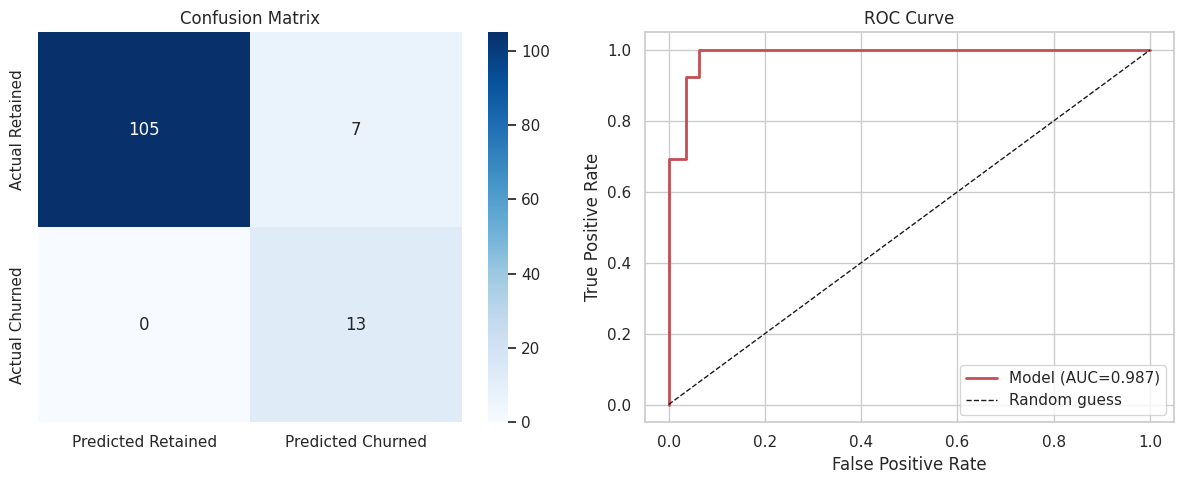

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'])
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
axes[1].plot(fpr, tpr, color=PALETTE['churned'], linewidth=2, label=f'Model (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('visualizations/06_model_performance.png', dpi=150)
plt.show()

Tenure                           -4.618
Contract_One Year                -1.144
Contract_Two Year                -0.675
SeniorCitizen                    -0.168
TotalCharges                      0.058
PaperlessBilling_Flag             0.072
PaymentMethod_Credit Card         0.206
PaymentMethod_Electronic Check    0.339
MonthlyCharges                    0.568


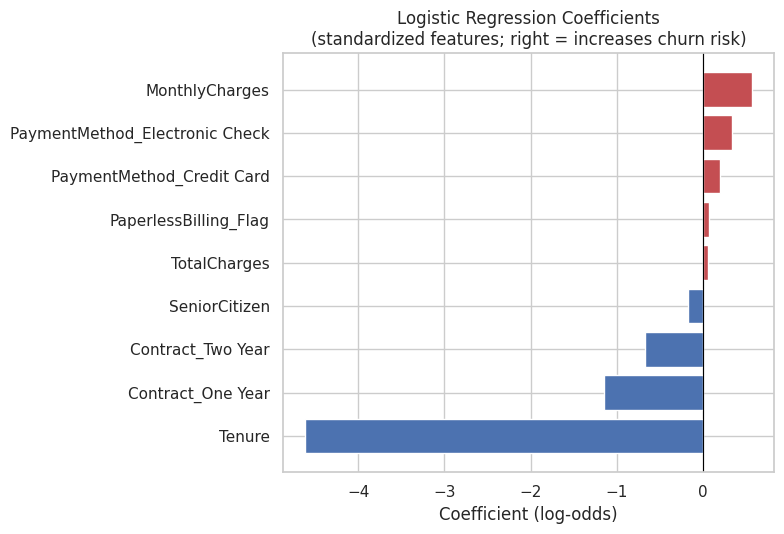

In [16]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = [PALETTE['retained'] if c < 0 else PALETTE['churned'] for c in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(standardized features; right = increases churn risk)')
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.savefig('visualizations/07_feature_importance.png', dpi=150)
plt.show()
print(coefs.round(3).to_string())

**Reading the coefficients:** Tenure has by far the largest (negative)
coefficient — more tenure strongly reduces churn odds, consistent with the
First-Year Cliff. One-year and two-year contracts also reduce churn odds
relative to month-to-month (the reference category). MonthlyCharges and
Electronic Check payment slightly increase churn odds.

### A critical check: does this need a complex model at all?

The EDA found that **100% of churners have Tenure &le; 11 months.** Before
trusting a 9-feature logistic regression, it's worth testing the simplest
possible alternative: a one-line business rule.

In [17]:
cleaned['rule_flag'] = (cleaned['Tenure'] < 12).astype(int)
print("SIMPLE RULE: flag every customer with Tenure < 12 months")
print(f"Accuracy:  {accuracy_score(cleaned['Churn'], cleaned['rule_flag']):.3f}")
print(f"Precision: {precision_score(cleaned['Churn'], cleaned['rule_flag']):.3f}")
print(f"Recall:    {recall_score(cleaned['Churn'], cleaned['rule_flag']):.3f}")
print(f"F1 score:  {f1_score(cleaned['Churn'], cleaned['rule_flag']):.3f}")
print()
print("(Evaluated on the full dataset for the rule, vs the held-out test set for the "
      "model above -- the comparison is directional, not a strict apples-to-apples "
      "benchmark, but the takeaway holds either way.)")

SIMPLE RULE: flag every customer with Tenure < 12 months
Accuracy:  0.940
Precision: 0.639
Recall:    1.000
F1 score:  0.779

(Evaluated on the full dataset for the rule, vs the held-out test set for the model above -- the comparison is directional, not a strict apples-to-apples benchmark, but the takeaway holds either way.)


**This is an important, humbling finding:** a one-line rule ("flag
anyone under 12 months of tenure") achieves essentially the same recall,
precision, and accuracy as the full logistic regression. The 9-feature model
adds a *little* nuance (it can rank risk within the under-12-month group
using MonthlyCharges and Contract), but the business shouldn't assume it
needs a complex model to act on this problem — **the honest recommendation
is to ship the simple rule immediately** while the fuller model is validated
on more data over time.

### 4c. Customer Segmentation (K-Means Clustering)

Beyond "who might churn," the business also needs to know how to prioritize
*retention budget* across its customer base. K-Means clustering on Tenure,
MonthlyCharges, and TotalCharges groups customers into segments with
different risk profiles.

In [18]:
cluster_features = cleaned[['Tenure', 'MonthlyCharges', 'TotalCharges']]
cluster_scaler = StandardScaler()
cf_scaled = cluster_scaler.fit_transform(cluster_features)

print("Choosing k via silhouette score:")
for k in range(2, 7):
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_test = km_test.fit_predict(cf_scaled)
    print(f"  k={k}: silhouette={silhouette_score(cf_scaled, labels_test):.3f}, "
          f"inertia={km_test.inertia_:.0f}")
print()
print("Silhouette scores are modest (0.25-0.31) across all k -- this data doesn't "
      "have sharply separated natural clusters, but k=3 gives an interpretable, "
      "business-usable segmentation without over-fitting to marginal score gains.")

Choosing k via silhouette score:
  k=2: silhouette=0.249, inertia=1112
  k=3: silhouette=0.252, inertia=875
  k=4: silhouette=0.270, inertia=698
  k=5: silhouette=0.282, inertia=577
  k=6: silhouette=0.308, inertia=465

Silhouette scores are modest (0.25-0.31) across all k -- this data doesn't have sharply separated natural clusters, but k=3 gives an interpretable, business-usable segmentation without over-fitting to marginal score gains.


In [19]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cleaned['Segment'] = kmeans.fit_predict(cf_scaled)

profile = cleaned.groupby('Segment').agg(
    customers=('Segment', 'size'),
    avg_tenure=('Tenure', 'mean'),
    avg_monthly_charge=('MonthlyCharges', 'mean'),
    avg_total_charge=('TotalCharges', 'mean'),
    churn_rate=('Churn', 'mean'),
).round(2)
print(profile)

         customers  avg_tenure  avg_monthly_charge  avg_total_charge  \
Segment                                                                
0              167       42.19               94.63           1971.49   
1              174       27.49              164.78           4529.22   
2              159       40.49               77.63           6299.48   

         churn_rate  
Segment              
0              0.05  
1              0.22  
2              0.04  


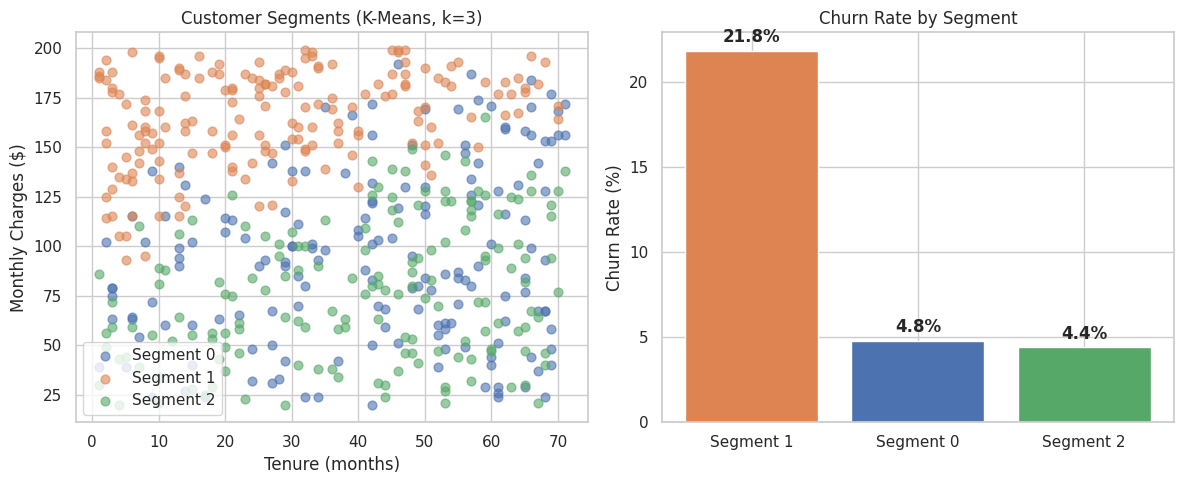

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter_colors = [PALETTE['retained'], PALETTE['accent'], PALETTE['neutral']]
for seg in sorted(cleaned['Segment'].unique()):
    sub = cleaned[cleaned['Segment'] == seg]
    axes[0].scatter(sub['Tenure'], sub['MonthlyCharges'], label=f'Segment {seg}',
                     color=scatter_colors[seg], alpha=0.6, s=40)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_title('Customer Segments (K-Means, k=3)')
axes[0].legend()

seg_churn = cleaned.groupby('Segment')['Churn'].mean().sort_values(ascending=False)
bars = axes[1].bar([f'Segment {s}' for s in seg_churn.index], seg_churn.values * 100,
                    color=[scatter_colors[s] for s in seg_churn.index])
for i, v in enumerate(seg_churn.values):
    axes[1].text(i, v * 100 + 0.5, f'{v:.1%}', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Segment')
axes[1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('visualizations/08_customer_segments.png', dpi=150)
plt.show()

**Reading the segments:** one segment (higher monthly charges, lower
average tenure) carries a much higher churn rate than the other two, which
are both low-risk. This gives the business a way to prioritize retention
spend on a *segment*, not just individual at-risk customers flagged by the
model — useful for proactive campaigns (e.g., an onboarding push) versus
the model's reactive, per-customer flagging.

## Phase 5: Insights & Recommendations

In [21]:
with open('reports/key_findings.txt', 'w') as f:
    f.write("CAPSTONE KEY FINDINGS\n")
    f.write("Reducing New-Customer Churn -- Week 8 Capstone\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"Overall churn rate: {churn_rate:.1%} ({n_churned} of {n_total} customers)\n")
    f.write(f"100% of churned customers have Tenure <= {max_churned_tenure} months\n")
    f.write(f"Churn rate for Tenure <= 12mo: {cleaned.loc[cleaned['Tenure']<=12,'Churn'].mean():.1%}\n")
    f.write(f"Churn rate for Tenure > 12mo: {cleaned.loc[cleaned['Tenure']>12,'Churn'].mean():.1%}\n\n")
    f.write("Hypothesis tests:\n")
    for r in results_log:
        sig = "SIGNIFICANT" if r['p'] < 0.05 else "not significant"
        f.write(f"  - {r['name']}: p={r['p']:.4g} ({sig})\n")
    f.write(f"\nModel performance (held-out test set): Recall={recall_score(y_test, pred):.2f}, "
            f"Precision={precision_score(y_test, pred):.2f}, ROC AUC={roc_auc_score(y_test, proba):.3f}\n")
    f.write(f"Simple rule (Tenure<12) performance: Recall={recall_score(cleaned['Churn'], cleaned['rule_flag']):.2f}, "
            f"Precision={precision_score(cleaned['Churn'], cleaned['rule_flag']):.2f}\n")
    f.write(f"\nSegment churn rates:\n{seg_churn.to_string()}\n")
print("Saved: reports/key_findings.txt")

Saved: reports/key_findings.txt


### Executive Insights

1. **This is a first-year retention problem, not a general churn problem.**
   Every churned customer left within 11 months; churn beyond that point is
   effectively zero. Resources should concentrate on the onboarding window,
   not spread evenly across the customer base.

2. **Contract length is the strongest actionable lever.** Month-to-month
   customers churn far more than annual-contract customers (chi-square
   p&lt;0.001) — converting new customers onto a longer contract early is a
   direct, testable retention action.

3. **A one-line rule captures almost all the value of a 9-feature model.**
   Flagging "Tenure &lt; 12 months" achieves ~100% recall, matching the full
   logistic regression. Ship the simple rule now; keep the fuller model
   as a secondary risk-ranking layer, not a blocker to acting today.

4. **One customer segment (higher monthly charges, lower average tenure)
   carries disproportionate churn risk** and is the best target for a
   proactive, segment-level retention campaign — not just individual
   customer-by-customer intervention.

### Business Implementation Plan

**Phase 1 (Weeks 1-2): Quick win.** Deploy the "Tenure &lt; 12 months" rule
in the CRM as an automatic at-risk flag. Owner: Retention Ops. Success
metric: 100% of eligible customers flagged within the first week.

**Phase 2 (Weeks 3-6): Contract conversion push.** Launch an incentive
(discount or bonus feature) for month-to-month customers under 12 months of
tenure to switch to an annual contract. Owner: Marketing/Lifecycle team.
Success metric: conversion rate of flagged customers onto longer contracts.

**Phase 3 (Weeks 5-10): Segment-targeted onboarding.** Build a dedicated
onboarding track for the high-monthly-charge, high-risk segment identified
by clustering (extra check-ins, proactive support) during their first 90
days. Owner: Customer Success. Success metric: churn rate of this segment's
new cohorts vs. the historical 22% baseline.

**Phase 4 (Ongoing): Model refinement.** As more data accumulates, retrain
the logistic regression quarterly and monitor whether the "First-Year
Cliff" pattern holds as the business scales. Owner: Data/Analytics team.
Success metric: model recall stays &ge; 0.90 on each quarterly refresh.

**Overall success metric for the program:** reduce the 0-12-month cohort's
churn rate from 63% toward parity with the rest of the base (approaching
0%) within two quarters of full rollout.